In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime


#1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-08-26,24.455648,24.686620,24.311575,24.563131,111065200
2016-08-29,24.428200,24.569985,24.306997,24.382463,99881200
2016-08-30,24.240683,24.355025,24.126340,24.194946,99455600
2016-08-31,24.263548,24.371030,24.158353,24.162927,118649600
2016-09-01,24.407610,24.423618,24.153769,24.272685,106806000
...,...,...,...,...,...
2026-08-19,316.829987,319.279999,309.600006,310.140015,50505600
2026-08-20,311.299988,320.279999,310.649994,317.459991,40959200


2. Data Exploration & Visualization


In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-08-26,24.455648,24.686620,24.311575,24.563131,111065200
2016-08-29,24.428200,24.569985,24.306997,24.382463,99881200
2016-08-30,24.240683,24.355025,24.126340,24.194946,99455600
2016-08-31,24.263548,24.371030,24.158353,24.162927,118649600
2016-09-01,24.407610,24.423618,24.153769,24.272685,106806000
...,...,...,...,...,...
2026-08-19,316.829987,319.279999,309.600006,310.140015,50505600
2026-08-20,311.299988,320.279999,310.649994,317.459991,40959200


In [4]:
type(df)

pandas.DataFrame

In [5]:
df.shape

(2512, 5)

In [6]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-08-26,24.455648,24.686620,24.311575,24.563131,111065200
2016-08-29,24.428200,24.569985,24.306997,24.382463,99881200
2016-08-30,24.240683,24.355025,24.126340,24.194946,99455600
2016-08-31,24.263548,24.371030,24.158353,24.162927,118649600
2016-09-01,24.407610,24.423618,24.153769,24.272685,106806000


In [7]:
df = df.reset_index()

In [8]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-08-26,24.455648,24.686620,24.311575,24.563131,111065200
1,2016-08-29,24.428200,24.569985,24.306997,24.382463,99881200
2,2016-08-30,24.240683,24.355025,24.126340,24.194946,99455600
3,2016-08-31,24.263548,24.371030,24.158353,24.162927,118649600
4,2016-09-01,24.407610,24.423618,24.153769,24.272685,106806000


Text(0, 0.5, 'Close price')

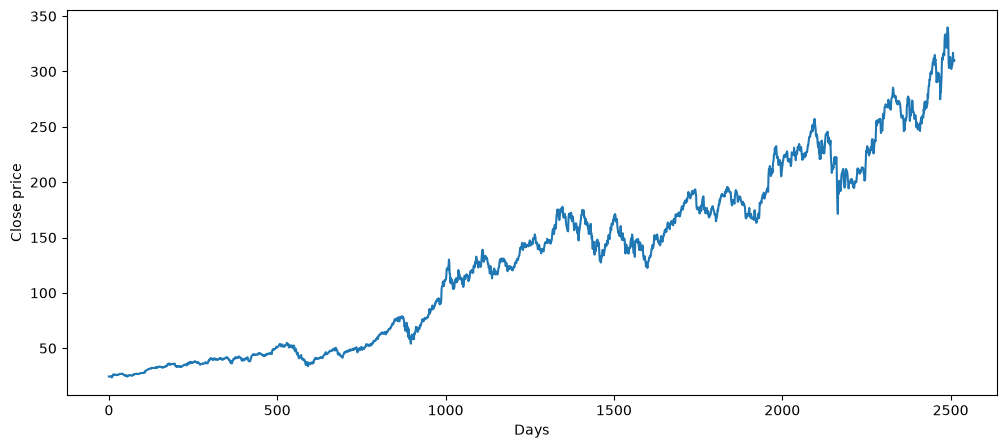

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
#plt.title(title)
plt.xlabel('Days')
plt.ylabel('Close price')


# 3. Feature Engineering

In [10]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[2:7])/5)


50.0


In [11]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1


,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [12]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()


Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-08-26,24.455648,24.686620,24.311575,24.563131,111065200,NaN
1,2016-08-29,24.428200,24.569985,24.306997,24.382463,99881200,NaN
2,2016-08-30,24.240683,24.355025,24.126340,24.194946,99455600,NaN
3,2016-08-31,24.263548,24.371030,24.158353,24.162927,118649600,NaN
4,2016-09-01,24.407610,24.423618,24.153769,24.272685,106806000,NaN


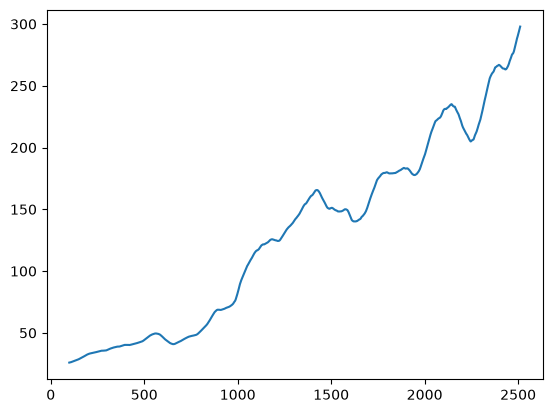

In [13]:
plt.plot(df['MA_100'])


Text(0, 0.5, 'Price')

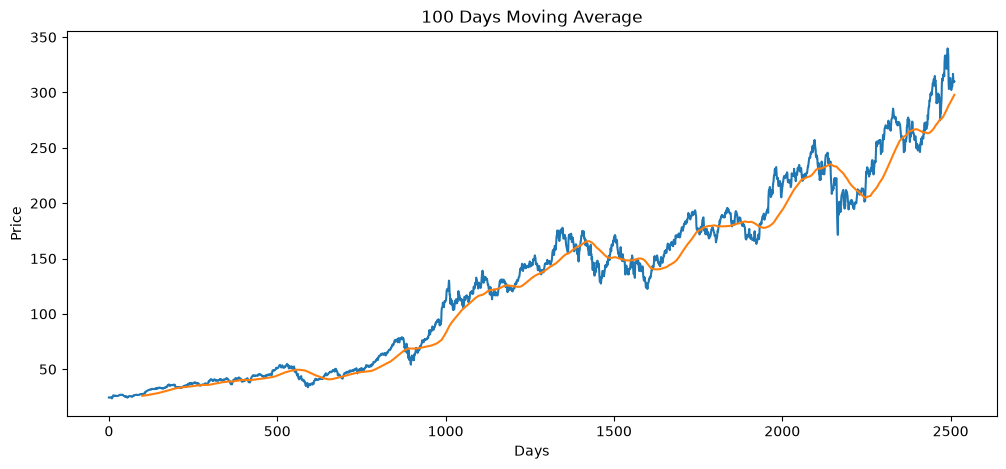

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'])
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')


KeyError: 'MA_200'

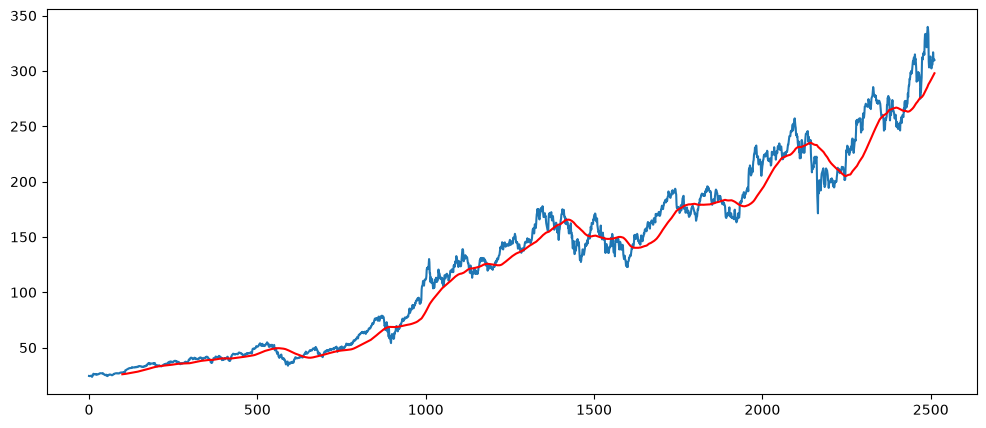

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')


In [ ]:
df['Percentage Chaged'] = df.Close.pct_change()
df[['Close', 'Percentage Chaged']]


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Chaged'])


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)


In [ ]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input


In [ ]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)


In [5]:
# Было:
# from keras.models import Sequential
# from keras.layers import Dense, LSTM, Input

# Должно быть:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

In [14]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

In [15]:
!pip install scikit-learn

In [17]:
import yfinance as yf

# Загружаем данные акций Apple (вы можете заменить 'AAPL' на любой другой тикер)
df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')

# Проверяем, что данные действительно загрузились
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.171764,24.638264,23.734006,24.627209,212818400
2015-01-05,23.490805,24.021421,23.305090,23.941828,257142000
2015-01-06,23.493008,23.751682,23.132630,23.554913,263188400
2015-01-07,23.822439,23.921929,23.590294,23.700839,160423600
2015-01-08,24.737745,24.795229,24.032468,24.149647,237458000


In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Берем цены закрытия
if isinstance(df.columns, pd.MultiIndex):
    close_data = df['Close'].iloc[:, 0].values.reshape(-1, 1)
else:
    close_data = df[['Close']].values

# Масштабируем данные
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_data)

# Разделяем и формируем выборки
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]

x_train, y_train = [], []
for i in range(100, len(train_data)):
    x_train.append(train_data[i-100:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [19]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0065
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 3.0304e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - loss: 2.7843e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 2.8748e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 2.6203e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - loss: 2.5148e-04
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 2.5265e-04
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 2.6375e-04
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - loss: 2.3969e-04
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 2.4681e-04
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 2.9537e-04
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 2.3185e-04
Epoch 13/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 2.3534e-04
Epoch 14/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 2.0844e-04
Epoch 

In [20]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [21]:
# Save the trained model
model.save('stock_prediction_model.keras')


In [22]:
data_testing

NameError: name 'data_testing' is not defined

In [23]:
# Создаем тестовую выборку из оставшейся части данных (20%)
data_testing = pd.DataFrame(scaled_data[train_size:])

# Проверяем результат
data_testing.head()

,0
0,0.723640
1,0.748597
2,0.773721
3,0.779472
4,0.798231
